In [1]:
import random 
import numpy as np
import glob
import cv2
from sklearn.utils import shuffle
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
import joblib

pssm_glob = 'psiblast/data/pssm/*.pssm'

In [2]:
protein_descritors = joblib.load("protein_descritors.pkl")

In [3]:
# Create expected outputs array from sec_strucure file DSSP
dataset_file = open("sec_structs.txt", "r")
protein_secundary_structure = {}
protein_aa = {}
x = 0
name = ""
for line in dataset_file:
    if (x%4==0):
        prot_name = line.strip()
    elif(x%4==1):
        protein_aa[prot_name] = line.strip()
    elif(x%4==3):
        protein_secundary_structure[prot_name] = line.strip()
    x+=1

proteins = list(protein_secundary_structure.keys())
print(len(proteins))

1461


In [4]:
# for each proteins, for each amino extracts PSSM window with AA centered.
from scipy.ndimage import shift

X_protein_features = {}

protein_index = 0
for protein in proteins:
    pssm = protein_descritors[protein]
    protein_features = np.zeros((len(pssm),20,13))

    translated_pssm = pssm.T
    offset_start=6
    #amino_class = []

    ix = 0
    for AA in range(0, len(pssm)):
        pssmmatrix = translated_pssm[:,AA+offset_start-6:AA+offset_start-6+13]
        pssmmatrix= shift(pssmmatrix, (0,offset_start), cval=0)
        if (len(pssmmatrix.T) <13):
            ncols = 13-len(pssmmatrix.T)
            aux = np.zeros((20,ncols), dtype="int8")
            pssmmatrix = np.hstack((pssmmatrix,aux))

        protein_features[ix] = pssmmatrix
        #amino_class.append(y_proteins[protein_index])
       
        if (offset_start >0):
            offset_start-=1
        ix+=1
   
    X_protein_features[protein] = protein_features
    protein_index +=1

In [5]:
print(len(proteins))
#remove proteins with wrong Structural information
for prot in proteins:
    if (len(X_protein_features[prot]) != len(protein_secundary_structure[prot])):
        #print(prot, len(X_protein_features[prot]), len(protein_secundary_structure[prot]))
        protein_secundary_structure.pop(prot)
    if (len(X_protein_features[prot])<30):
        protein_secundary_structure.pop(prot)
        
proteins = list(protein_secundary_structure.keys())
print(len(proteins))

1461
1427


In [6]:
proteins = proteins[:]

In [115]:
np.set_printoptions(formatter={'float': lambda x: "{0:0.2f}".format(x)})
protein_general_features = np.zeros((len(proteins), 8))
ix = 0
for protein in proteins:
    protein_general_features_aux = np.zeros((8));
    
    for aa in protein_aa[protein]:
        if (aa=='A' or aa=='G' or aa=='V' ):
            protein_general_features_aux[1] += 1;
        elif (aa=='I' or aa=='L' or aa=='F' or  aa=='P'):
            protein_general_features_aux[2] += 1;
        elif (aa=='Y' or aa=='M' or aa=='T' or  aa=='S'):
            protein_general_features_aux[3] += 1;
        elif (aa=='H' or aa=='N' or aa=='Q' or  aa=='W'):
            protein_general_features_aux[4] += 1;    
        elif (aa=='R' or aa=='K'):
            protein_general_features_aux[5] += 1;
        elif (aa=='D' or aa=='E'):
            protein_general_features_aux[6] += 1;
        elif (aa=='C'):
            protein_general_features_aux[7] += 1;
    
    protein_general_features_aux = protein_general_features_aux/len(protein_aa[protein])
    protein_general_features_aux[0] = len(protein_aa[protein])
    protein_general_features[ix,:] = protein_general_features_aux
    ix+=1

In [116]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(protein_general_features)
protein_general_features = scaler.transform(protein_general_features)

In [117]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(protein_general_features)
after_pca = pca.transform(protein_general_features)

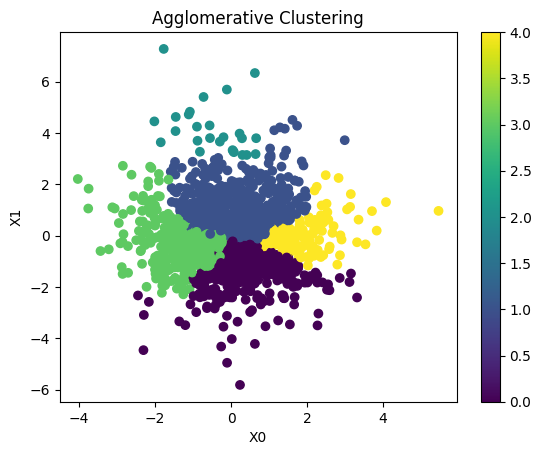

In [118]:
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(linkage="complete", affinity="euclidean", n_clusters=5)

model = model.fit(after_pca)
cluster_labels = model.fit_predict(after_pca)

fig = plt.figure(); ax = fig.add_subplot(111)
scatter = ax.scatter(after_pca[:,1],after_pca[:,0], c=cluster_labels)
ax.set_title("Agglomerative Clustering")
ax.set_xlabel("X0"); ax.set_ylabel("X1")
plt.colorbar(scatter); plt.show()

protein_cluster_assign= {}
ix = 0
for protein in proteins:
    protein_cluster_assign[protein] = cluster_labels[ix]
    ix+=1

In [132]:
print(after_pca.shape)
print(cluster_labels.shape)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(after_pca, cluster_labels) 
predicted = knn.predict(after_pca)
print("Predictions from the classifier:")
print(predicted)
print("Target values:")
print(cluster_labels)

#kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(after_pca)

(1427, 2)
(1427,)
Predictions from the classifier:
[0 4 0 ... 0 1 1]
Target values:
[0 4 0 ... 0 1 1]


In [11]:
from sklearn.model_selection import train_test_split

proteins_train, proteins_test = train_test_split(proteins, test_size=0.30, random_state=42)

In [12]:
dataset_sizes = {}
dataset_sizes_test = {}

data_targets = {}
data_targets_test = {}


dataset_positions = {}
dataset_positions_test = {}


for p in proteins_train:
    if (protein_cluster_assign[p] not in dataset_sizes.keys()):
        dataset_sizes[protein_cluster_assign[p]]=len(X_protein_features[p])
        dataset_positions[protein_cluster_assign[p]]=0
    else:
        dataset_sizes[protein_cluster_assign[p]]+=len(X_protein_features[p])

for p in proteins_test:
    if (protein_cluster_assign[p] not in dataset_sizes_test.keys()):
        dataset_sizes_test[protein_cluster_assign[p]]=len(X_protein_features[p])
        dataset_positions_test[protein_cluster_assign[p]]=0
    else:
        dataset_sizes_test[protein_cluster_assign[p]]+=len(X_protein_features[p])
        
print(dataset_sizes)
print(dataset_sizes_test)


{1: 205246, 3: 69009, 0: 73352, 2: 2898, 4: 63233}
{4: 33635, 1: 62820, 3: 29819, 0: 25236, 2: 2169}


In [13]:
training_datasets = {}
for k in dataset_sizes.keys():
    training_datasets[k] = np.zeros((dataset_sizes[k], 20, 13))
for k in dataset_sizes.keys():
    data_targets[k] = []
    
testing_datasets = {}
for k in dataset_sizes_test.keys():
    testing_datasets[k] = np.zeros((dataset_sizes_test[k], 20, 13))
for k in dataset_sizes.keys():
    data_targets_test[k] = []

In [14]:
print(training_datasets[0].shape) # check
print(testing_datasets[0].shape) # check
print(dataset_positions)
print(dataset_positions_test)


(73352, 20, 13)
(25236, 20, 13)
{1: 0, 3: 0, 0: 0, 2: 0, 4: 0}
{4: 0, 1: 0, 3: 0, 0: 0, 2: 0}


In [15]:
# Put data in place
print(dataset_positions)
for p in proteins_train:
    #print(protein_cluster_assign[p])
    for AA in X_protein_features[p]:
        training_datasets[protein_cluster_assign[p]][dataset_positions[protein_cluster_assign[p]]] = AA
        dataset_positions[protein_cluster_assign[p]] += 1
    for S in protein_secundary_structure[p]:
        data_targets[protein_cluster_assign[p]].append(S)
        
print(dataset_positions_test)
for p in proteins_test:
    #print(protein_cluster_assign[p])
    for AA in X_protein_features[p]:
        testing_datasets[protein_cluster_assign[p]][dataset_positions_test[protein_cluster_assign[p]]] = AA
        dataset_positions_test[protein_cluster_assign[p]] += 1
    for S in protein_secundary_structure[p]:
        data_targets_test[protein_cluster_assign[p]].append(S)

{1: 0, 3: 0, 0: 0, 2: 0, 4: 0}
{4: 0, 1: 0, 3: 0, 0: 0, 2: 0}


In [16]:
from sklearn import preprocessing

for k in data_targets.keys():
    le = preprocessing.LabelEncoder()
    le.fit(data_targets[k])
    data_targets[k] = le.transform(data_targets[k])
    
for k in data_targets.keys():
    le = preprocessing.LabelEncoder()
    le.fit(data_targets_test[k])
    data_targets_test[k] = le.transform(data_targets_test[k])

In [17]:
import keras

INPUT_SHAPE = (20, 13, 1)  
inp = keras.layers.Input(shape=INPUT_SHAPE)
conv1 = keras.layers.Conv2D(500, kernel_size=(5, 5), activation='relu', padding='same')(inp)
pool1 = keras.layers.MaxPooling2D(pool_size=(2, 2))(conv1)
conv2 = keras.layers.Conv2D(100, kernel_size=(2, 2), activation='relu', padding='same')(pool1)
flat = keras.layers.Flatten()(conv2)  #Flatten the matrix to get it ready for dense.
hidden1 = keras.layers.Dense(50, activation='relu')(flat)
out = keras.layers.Dense(3, activation='softmax')(hidden1)   #units=1 gives error

model0 = keras.Model(inputs=inp, outputs=out)
model0.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
print(model0.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 13, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 20, 13, 500)       13000     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 10, 6, 500)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 6, 100)        200100    
                                                                 
 flatten (Flatten)           (None, 6000)              0         
                                                                 
 dense (Dense)               (None, 50)                300050    
                                                             

In [18]:
model1 = keras.Model(inputs=inp, outputs=out)
model1.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
print(model1.summary())


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 13, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 20, 13, 500)       13000     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 10, 6, 500)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 6, 100)        200100    
                                                                 
 flatten (Flatten)           (None, 6000)              0         
                                                                 
 dense (Dense)               (None, 50)                300050    
                                                           

In [19]:
model2 = keras.Model(inputs=inp, outputs=out)
model2.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
print(model2.summary())

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 13, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 20, 13, 500)       13000     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 10, 6, 500)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 6, 100)        200100    
                                                                 
 flatten (Flatten)           (None, 6000)              0         
                                                                 
 dense (Dense)               (None, 50)                300050    
                                                           

In [20]:
model3 = keras.Model(inputs=inp, outputs=out)
model3.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
print(model3.summary())

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 13, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 20, 13, 500)       13000     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 10, 6, 500)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 6, 100)        200100    
                                                                 
 flatten (Flatten)           (None, 6000)              0         
                                                                 
 dense (Dense)               (None, 50)                300050    
                                                           

In [21]:
model4 = keras.Model(inputs=inp, outputs=out)
model4.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
print(model4.summary())

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 13, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 20, 13, 500)       13000     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 10, 6, 500)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 6, 100)        200100    
                                                                 
 flatten (Flatten)           (None, 6000)              0         
                                                                 
 dense (Dense)               (None, 50)                300050    
                                                           

In [22]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

history = model0.fit(training_datasets[0],
                         to_categorical(np.array(list(data_targets[0]))),
                         batch_size = 128,
                         verbose = 1,
                         epochs = 5,      #Changed to 3 from 50 for testing purposes.
                         validation_split = 0.2,
                         shuffle = False
                      #   callbacks=callbacks
                     )

print("Test_Accuracy: {:.2f}%".format(model0.evaluate(testing_datasets[0], to_categorical(np.array(list(data_targets_test[0]))) )[1]*100))



Epoch 1/5
459/459 [==============================] - 54s 117ms/step - loss: 0.7926 - accuracy: 0.6516 - val_loss: 0.7454 - val_accuracy: 0.6884
Epoch 2/5
459/459 [==============================] - 53s 116ms/step - loss: 0.6829 - accuracy: 0.7118 - val_loss: 0.7860 - val_accuracy: 0.6828
Epoch 3/5
459/459 [==============================] - 54s 118ms/step - loss: 0.6394 - accuracy: 0.7333 - val_loss: 0.7355 - val_accuracy: 0.6946
Epoch 4/5
459/459 [==============================] - 53s 115ms/step - loss: 0.6005 - accuracy: 0.7517 - val_loss: 0.7490 - val_accuracy: 0.7035
Epoch 5/5
789/789 [==============================] - 7s 9ms/step - loss: 0.7332 - accuracy: 0.7118
Test_Accuracy: 71.18%


In [23]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

history = model1.fit(training_datasets[1],
                         to_categorical(np.array(list(data_targets[1]))),
                         batch_size = 128,
                         verbose = 1,
                         epochs = 5,      #Changed to 3 from 50 for testing purposes.
                         validation_split = 0.2,
                         shuffle = False
                      #   callbacks=callbacks
                     )

print("Test_Accuracy: {:.2f}%".format(model1.evaluate(testing_datasets[1], to_categorical(np.array(list(data_targets_test[1]))) )[1]*100))



Epoch 1/5
1283/1283 [==============================] - 152s 118ms/step - loss: 0.6801 - accuracy: 0.7152 - val_loss: 0.7397 - val_accuracy: 0.6865
Epoch 2/5
1283/1283 [==============================] - 146s 114ms/step - loss: 0.6159 - accuracy: 0.7417 - val_loss: 0.7335 - val_accuracy: 0.6943
Epoch 3/5
1283/1283 [==============================] - 150s 117ms/step - loss: 0.5527 - accuracy: 0.7698 - val_loss: 0.7265 - val_accuracy: 0.6994
Epoch 4/5
1283/1283 [==============================] - 152s 119ms/step - loss: 0.4873 - accuracy: 0.7975 - val_loss: 0.8163 - val_accuracy: 0.6788
Epoch 5/5
1964/1964 [==============================] - 16s 8ms/step - loss: 1.0261 - accuracy: 0.6604
Test_Accuracy: 66.04%


In [24]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

history = model2.fit(training_datasets[2],
                         to_categorical(np.array(list(data_targets[2]))),
                         batch_size = 128,
                         verbose = 1,
                         epochs = 5,      #Changed to 3 from 50 for testing purposes.
                         validation_split = 0.2,
                         shuffle = False
                      #   callbacks=callbacks
                     )

print("Test_Accuracy: {:.2f}%".format(model2.evaluate(testing_datasets[2], to_categorical(np.array(list(data_targets_test[2]))) )[1]*100))


Epoch 1/5
19/19 [==============================] - 3s 126ms/step - loss: 0.9800 - accuracy: 0.6135 - val_loss: 0.9460 - val_accuracy: 0.5776
Epoch 2/5
19/19 [==============================] - 2s 115ms/step - loss: 0.7370 - accuracy: 0.6894 - val_loss: 0.8122 - val_accuracy: 0.6431
Epoch 3/5
19/19 [==============================] - 2s 121ms/step - loss: 0.6077 - accuracy: 0.7321 - val_loss: 0.8593 - val_accuracy: 0.6276
Epoch 4/5
19/19 [==============================] - 2s 118ms/step - loss: 0.5016 - accuracy: 0.7774 - val_loss: 0.9055 - val_accuracy: 0.6276
Epoch 5/5
68/68 [==============================] - 1s 9ms/step - loss: 1.0602 - accuracy: 0.6362
Test_Accuracy: 63.62%


In [25]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

history = model3.fit(training_datasets[3],
                         to_categorical(np.array(list(data_targets[3]))),
                         batch_size = 128,
                         verbose = 1,
                         epochs = 5,      #Changed to 3 from 50 for testing purposes.
                         validation_split = 0.2,
                         shuffle = False
                      #   callbacks=callbacks
                     )

#print("Test_Accuracy: {:.2f}%".format(model3.evaluate(testing_datasets[3], to_categorical(np.array(list(data_targets_test[3]))) )[1]*100))


Epoch 1/5
432/432 [==============================] - 52s 120ms/step - loss: 0.7232 - accuracy: 0.6925 - val_loss: 0.7474 - val_accuracy: 0.6668
Epoch 2/5
432/432 [==============================] - 49s 114ms/step - loss: 0.6232 - accuracy: 0.7349 - val_loss: 0.7574 - val_accuracy: 0.6744
Epoch 3/5
432/432 [==============================] - 51s 119ms/step - loss: 0.5459 - accuracy: 0.7708 - val_loss: 0.7737 - val_accuracy: 0.6915
Epoch 4/5
432/432 [==============================] - 52s 119ms/step - loss: 0.4669 - accuracy: 0.8056 - val_loss: 0.8866 - val_accuracy: 0.6766
Epoch 5/5
432/432 [==============================] - 50s 116ms/step - loss: 0.3945 - accuracy: 0.8385 - val_loss: 0.9443 - val_accuracy: 0.6820


In [26]:
print("Test_Accuracy: {:.2f}%".format(model3.evaluate(testing_datasets[3], to_categorical(np.array(list(data_targets_test[3]))) )[1]*100))


932/932 [==============================] - 8s 9ms/step - loss: 0.9727 - accuracy: 0.6822
Test_Accuracy: 68.22%


In [27]:
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

history = model4.fit(training_datasets[4],
                         to_categorical(np.array(list(data_targets[4]))),
                         batch_size = 128,
                         verbose = 1,
                         epochs = 5,      #Changed to 3 from 50 for testing purposes.
                         validation_split = 0.2,
                         shuffle = False
                      #   callbacks=callbacks
                     )

print("Test_Accuracy: {:.2f}%".format(model4.evaluate(testing_datasets[4], to_categorical(np.array(list(data_targets_test[4]))) )[1]*100))


Epoch 1/5
396/396 [==============================] - 46s 115ms/step - loss: 0.6283 - accuracy: 0.7419 - val_loss: 0.6284 - val_accuracy: 0.7214
Epoch 2/5
396/396 [==============================] - 49s 123ms/step - loss: 0.4939 - accuracy: 0.7967 - val_loss: 0.6248 - val_accuracy: 0.7187
Epoch 3/5
396/396 [==============================] - 48s 121ms/step - loss: 0.3928 - accuracy: 0.8385 - val_loss: 0.6654 - val_accuracy: 0.7299
Epoch 4/5
396/396 [==============================] - 48s 122ms/step - loss: 0.3101 - accuracy: 0.8751 - val_loss: 0.7263 - val_accuracy: 0.7226
Epoch 5/5
1052/1052 [==============================] - 9s 9ms/step - loss: 1.0389 - accuracy: 0.6759
Test_Accuracy: 67.59%


In [28]:
y_train = []
for prot_name in proteins_train:
    for S in protein_secundary_structure[prot_name]:
        y_train.append(S)
print(len(y_train))

y_test = []
for prot_name in proteins_test:
    for S in protein_secundary_structure[prot_name]:
        y_test.append(S)
print(len(y_test))

X_train = np.zeros((len(y_train), 20,13))
aa_ix = 0
for prot in proteins_train:
    for AA in X_protein_features[prot]:
        X_train[aa_ix] = AA
        aa_ix += 1

X_test = np.zeros((len(y_test), 20,13))
aa_ix = 0
for prot in proteins_test:
    for AA in X_protein_features[prot]:
        X_test[aa_ix] = AA
        aa_ix += 1
        
print(X_train.shape)
print(X_test.shape)

413738
153679
(413738, 20, 13)
(153679, 20, 13)


In [29]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)


In [41]:
model0 = keras.models.load_model('model0')
model1 = keras.models.load_model('model1')
model2 = keras.models.load_model('model2')
model3 = keras.models.load_model('model3')
model4 = keras.models.load_model('model4')


In [42]:
y0 = model0.predict (X_train)
y1 = model1.predict (X_train)
y2 = model2.predict (X_train)
y3 = model3.predict (X_train)
y4 = model4.predict (X_train)

12930/12930 [==============================] - 134s 10ms/step


In [43]:
yt0 = model0.predict (X_test)
yt1 = model1.predict (X_test)
yt2 = model2.predict (X_test)
yt3 = model3.predict (X_test)
yt4 = model4.predict (X_test)

4803/4803 [==============================] - 50s 10ms/step


In [49]:
cluster_assign_train = np.zeros(len(y_train))
cluster_assign_test = np.zeros(len(y_test))

aa_ix = 0
for prot in proteins_train:
    for AA in X_protein_features[prot]:
        cluster_assign_train[aa_ix]=protein_cluster_assign[prot]
        aa_ix += 1

aa_ix = 0
for prot in proteins_test:
    for AA in X_protein_features[prot]:
        cluster_assign_test[aa_ix]=protein_cluster_assign[prot]
        aa_ix += 1


In [50]:
trainning_all = np.concatenate((y0,y1,y2,y3,y4), axis=1)
testing_all =  np.concatenate((yt0,yt1,yt2,yt3,yt4), axis=1)

In [51]:
trainning_all = np.c_[cluster_assign_train, trainning_all]
testing_all = np.c_[cluster_assign_test, testing_all]

In [35]:
trainning_all.shape

(413738, 16)

In [68]:
INPUT_SHAPE =  (16)  
inp = keras.layers.Input(shape=INPUT_SHAPE)
hidden1 = keras.layers.Dense(5, activation='relu')(inp)
out = keras.layers.Dense(3, activation='softmax')(hidden1)   #units=1 gives error
modelf = keras.Model(inputs=inp, outputs=out)
modelf.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
print(modelf.summary())


Model: "model_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 16)]              0         
                                                                 
 dense_20 (Dense)            (None, 5)                 85        
                                                                 
 dense_21 (Dense)            (None, 3)                 18        
                                                                 
Total params: 103
Trainable params: 103
Non-trainable params: 0
_________________________________________________________________
None


In [37]:
'''from sklearn import svm
clf = svm.SVC(kernel='rbf', C= 10.0, gamma= 0.001) # rbf Kernel
clf.fit(trainning_all, y_train)
from sklearn import metrics
y_pred = clf.predict(testing_all)
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred, average = 'weighted'))
print("Recall:",metrics.recall_score(y_test, y_pred, average = 'weighted'))
'''

'from sklearn import svm\nclf = svm.SVC(kernel=\'rbf\', C= 10.0, gamma= 0.001) # rbf Kernel\nclf.fit(trainning_all, y_train)\nfrom sklearn import metrics\ny_pred = clf.predict(testing_all)\nprint("Accuracy:",metrics.accuracy_score(y_test, y_pred))\nprint("Precision:",metrics.precision_score(y_test, y_pred, average = \'weighted\'))\nprint("Recall:",metrics.recall_score(y_test, y_pred, average = \'weighted\'))\n'

In [69]:
history = modelf.fit(trainning_all,
                         to_categorical(np.array(list(y_train))),
                         batch_size = 128,
                         verbose = 1,
                         epochs = 5,      #Changed to 3 from 50 for testing purposes.
                         validation_split = 0.2,
                         shuffle = False
                      #   callbacks=callbacks
                     )

print("Test_Accuracy: {:.2f}%".format(modelf.evaluate(testing_all, to_categorical(np.array(list(y_test))) )[1]*100))

Epoch 1/5
2586/2586 [==============================] - 3s 948us/step - loss: 0.7077 - accuracy: 0.7032 - val_loss: 0.6747 - val_accuracy: 0.7224
Epoch 2/5
2586/2586 [==============================] - 2s 910us/step - loss: 0.6452 - accuracy: 0.7318 - val_loss: 0.6666 - val_accuracy: 0.7234
Epoch 3/5
2586/2586 [==============================] - 2s 919us/step - loss: 0.6394 - accuracy: 0.7329 - val_loss: 0.6630 - val_accuracy: 0.7242
Epoch 4/5
2586/2586 [==============================] - 2s 912us/step - loss: 0.6365 - accuracy: 0.7335 - val_loss: 0.6620 - val_accuracy: 0.7235
Epoch 5/5
4803/4803 [==============================] - 3s 678us/step - loss: 0.6915 - accuracy: 0.7079
Test_Accuracy: 70.79%


In [80]:

# Study for a single protein:
# 1 generate pssm
# C:/Users/Igor/Desktop/newproject/newdataset/psiblast/ncbi-blast-2.13.0+/bin/psiblast -query C:\Users\Igor\Desktop\newproject\psiblast\data\sequences\5xg0.seq -db swissprot -out C:\Users\Igor\Desktop\newproject\psiblast\data\out\6xg0.out -num_iterations 3 -out_ascii_pssm C:/Users/Igor/Desktop/newproject/newdataset/psiblast/data/pssm/5xg0.pssm -inclusion_ethresh 0.001  -save_pssm_after_last_round -comp_based_stats 0 -num_threads 1
# 2 extract pssm 

def read_matrix_from_pssm_file(fname):
    nrows=0
    with open(fname) as txt_file:    # Count rows.
        for line in txt_file:
            l = line.strip().split()
            if (len(l) == 44):
                nrows+=1;
    matrix = np.zeros((nrows,20), dtype="int8")
    i=0
    with open(fname) as txt_file: # Read PSSM.
        for line in txt_file:
            l = line.strip().split()
            if (len(l) == 44):
                values = np.array(list(map(int, l[2:22])))
                matrix[i,:] = values
                i+=1
    return matrix

# LOAD PSSM Matrices into protein_descriptors
input_protein_descritors = {}
file = "C:/Users/Igor/Desktop/newproject/newdataset/psiblast/data/pssm/5xg0.pssm"
input_aa_sequence = "GAGAGAMNPYARGPNPTAASLEASAGPFTVRSFTVSRPSGYGAGTVYYPTNAGGTVGAIAIVPGYTARQSSIKWWGPRLASHGFVVITIDTNSTLDQPSSRSSQQMAALRQVASLNGTSSSPIYGKVDTARMGVMGWSMGGGGSLISAANNPSLKAAAPQAPWDSSTNFSSVTVPTLIFACENDSIAPVNSSALPIYDSMSRNAKQFLEINGGSHSCANSGNSNQALIGKKGVAWMKRFMDNDTRYSTFACENPNSTRVSDFRTANCS"
pssm_matrix = read_matrix_from_pssm_file(file)
prot_name = "5xg0"
input_protein_descritors[prot_name] = pssm_matrix 

print("PSSM Matrixes read:")
print(len(input_protein_descritors))
#joblib.dump(protein_descritors,"protein_descritors.pkl", compress=3)

PSSM Matrixes read:
1


In [133]:
# for each proteins, for each amino extracts PSSM window with AA centered.
from scipy.ndimage import shift

X_protein_features = {}

protein_index = 0

pssm = input_protein_descritors[prot_name]
input_protein_features = np.zeros((len(pssm),20,13))

translated_pssm = pssm.T
offset_start=6
#amino_class = []

ix = 0
for AA in range(0, len(pssm)):
    pssmmatrix = translated_pssm[:,AA+offset_start-6:AA+offset_start-6+13]
    pssmmatrix= shift(pssmmatrix, (0,offset_start), cval=0)
    if (len(pssmmatrix.T) <13):
        ncols = 13-len(pssmmatrix.T)
        aux = np.zeros((20,ncols), dtype="int8")
        pssmmatrix = np.hstack((pssmmatrix,aux))

    input_protein_features[ix] = pssmmatrix
    #amino_class.append(y_proteins[protein_index])

    if (offset_start >0):
        offset_start-=1
    ix+=1
    
print(input_protein_features.shape)

(268, 20, 13)


In [134]:
input_protein_general_features_aux = np.zeros((8));
    
for aa in input_aa_sequence:
    if (aa=='A' or aa=='G' or aa=='V' ):
        input_protein_general_features_aux[1] += 1;
    elif (aa=='I' or aa=='L' or aa=='F' or  aa=='P'):
        input_protein_general_features_aux[2] += 1;
    elif (aa=='Y' or aa=='M' or aa=='T' or  aa=='S'):
        input_protein_general_features_aux[3] += 1;
    elif (aa=='H' or aa=='N' or aa=='Q' or  aa=='W'):
        input_protein_general_features_aux[4] += 1;    
    elif (aa=='R' or aa=='K'):
        input_protein_general_features_aux[5] += 1;
    elif (aa=='D' or aa=='E'):
        input_protein_general_features_aux[6] += 1;
    elif (aa=='C'):
        input_protein_general_features_aux[7] += 1;

input_protein_general_features_aux = input_protein_general_features_aux/len(input_aa_sequence)
input_protein_general_features_aux[0] = len(input_aa_sequence)
print(input_protein_general_features_aux)

[268.00 0.28 0.18 0.27 0.13 0.07 0.05 0.01]


In [135]:
input_protein_general_features_aux = scaler.transform(input_protein_general_features_aux.reshape(1, -1))
input_protein_general_features_aux

array([[-0.22, 1.19, -1.08, 2.32, 0.13, -1.15, -2.34, -0.06]])

In [136]:
after_pca = pca.transform(input_protein_general_features_aux)
print(after_pca)

[[3.48 0.27]]


In [142]:
input_cluster = np.repeat(knn.predict(after_pca)[0], len(input_protein_features)) 

In [140]:
y0 = model0.predict (input_protein_features)
y1 = model1.predict (input_protein_features)
y2 = model2.predict (input_protein_features)
y3 = model3.predict (input_protein_features)
y4 = model4.predict (input_protein_features)

9/9 [==============================] - 0s 9ms/step


In [143]:
in_prot = np.concatenate((y0,y1,y2,y3,y4), axis=1)
in_prot = np.c_[input_cluster, in_prot]

In [145]:
predicted = modelf.predict(in_prot)

9/9 [==============================] - 0s 875us/step


In [175]:
predicted
predict_class = np.argmax(predicted, axis=1)
predict_class = predict_class.tolist()

"".join(le.inverse_transform(predict_class))

'CCCCCCCCCCCCCCCCCCHCHCCCCCCCCCCEEEEEECCCCCEEEEEECCCCCCCCEEEEEECCCCCCHHHHHHHHHHHHHCCEEEEEEECCCCCCCCCCCHHHCHHHHHHHHHHHHHHHHHHHHCCCCCEEEEEEECHHHHHHHHHHHCCCCCCEEEEECCCCCHHHHCCCCCHEEEEECCCCCECCHHHHHHHHHHHCCCCCCEEEEECCCCCECCCCCCCHHHHHHHHHHHHHHHHHCCCCCCCEEEECCCCCCCCCCCCCCCCC'